# Global Climate Change Data Analysis

Analyzing global temperature trends across regions using statistical methods including t-tests, ANOVA, and Pearson correlation.

In [1]:
# Import the libraries we need
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, f_oneway, pearsonr

## Section 1: Load and Clean the Data

In [2]:
# Load the dataset from GitHub
DATA_URL = "https://raw.githubusercontent.com/csbfx/cs22a/main/global_climate.csv"
df = pd.read_csv(DATA_URL)

# Preview the data
print("Shape:", df.shape)
print(df.head())

Shape: (7964, 5)
   Region  Country     City  Year  AvgTemperature
0  Africa  Algeria  Algiers  1995       64.410468
1  Africa  Algeria  Algiers  1996       63.530220
2  Africa  Algeria  Algiers  1997       64.926301
3  Africa  Algeria  Algiers  1998       63.619668
4  Africa  Algeria  Algiers  1999       64.923626


In [3]:
# Check for missing values and remove them
print("Missing values before cleaning:")
print(df.isnull().sum())

df = df.dropna()

print("\nRows after cleaning:", len(df))
print("Regions in dataset:", df["Region"].unique())

Missing values before cleaning:
Region            0
Country           0
City              0
Year              0
AvgTemperature    0
dtype: int64

Rows after cleaning: 7964
Regions in dataset: ['Africa' 'Asia' 'Australia/South Pacific' 'Europe' 'Middle East'
 'North America' 'South/Central America & Carribean']


## Section 2: Summary Statistics by Region

In [4]:
# Get the list of unique regions
regions = df["Region"].unique()

# Loop through each region and print basic stats
for region in regions:
    region_df = df[df["Region"] == region]
    mean_temp = region_df["AvgTemperature"].mean()
    median_temp = region_df["AvgTemperature"].median()
    city_count = region_df["City"].nunique()

    print(f"Region: {region}")
    print(f"  Mean Temperature: {mean_temp:.2f} F")
    print(f"  Median Temperature: {median_temp:.2f} F")
    print(f"  Number of Cities: {city_count}")
    print()

Region: Africa
  Mean Temperature: 74.50 F
  Median Temperature: 77.13 F
  Number of Cities: 29

Region: Asia
  Mean Temperature: 68.09 F
  Median Temperature: 72.79 F
  Number of Cities: 35

Region: Australia/South Pacific
  Mean Temperature: 62.45 F
  Median Temperature: 63.44 F
  Number of Cities: 6

Region: Europe
  Mean Temperature: 51.87 F
  Median Temperature: 51.60 F
  Number of Cities: 45

Region: Middle East
  Mean Temperature: 73.73 F
  Median Temperature: 79.64 F
  Number of Cities: 14

Region: North America
  Mean Temperature: 55.93 F
  Median Temperature: 54.80 F
  Number of Cities: 167

Region: South/Central America & Carribean
  Mean Temperature: 72.63 F
  Median Temperature: 75.34 F
  Number of Cities: 25



## Section 3: T-Test — Did temperatures increase after 2010?

In [5]:
# For each region, compare average temperatures before and after 2010
# A low p-value (< 0.05) means the difference is statistically significant

for region in regions:
    region_df = df[df["Region"] == region]

    before = region_df[region_df["Year"] < 2010]["AvgTemperature"]
    after = region_df[region_df["Year"] >= 2010]["AvgTemperature"]

    t_stat, p_value = ttest_ind(before, after)

    result = "Significant" if p_value < 0.05 else "Not significant"

    print(f"Region: {region}")
    print(f"  T-Statistic: {t_stat:.2f}")
    print(f"  P-Value: {p_value:.4f} -> {result}")
    print()

Region: Africa
  T-Statistic: -0.65
  P-Value: 0.5163 -> Not significant

Region: Asia
  T-Statistic: 0.73
  P-Value: 0.4649 -> Not significant

Region: Australia/South Pacific
  T-Statistic: -1.60
  P-Value: 0.1106 -> Not significant

Region: Europe
  T-Statistic: 1.32
  P-Value: 0.1886 -> Not significant

Region: Middle East
  T-Statistic: -0.66
  P-Value: 0.5085 -> Not significant

Region: North America
  T-Statistic: -0.25
  P-Value: 0.8042 -> Not significant

Region: South/Central America & Carribean
  T-Statistic: -0.89
  P-Value: 0.3746 -> Not significant



## Section 4: ANOVA — Are temperatures significantly different across regions?

In [6]:
# Collect temperature data for each region into a list
region_temps = []
for region in regions:
    temps = df[df["Region"] == region]["AvgTemperature"].dropna()
    region_temps.append(temps)

# Run one-way ANOVA
f_stat, p_value = f_oneway(*region_temps)

print("One-Way ANOVA Results:")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Temperature differences across regions are statistically significant.")
else:
    print("Result: No significant difference found across regions.")

One-Way ANOVA Results:
F-Statistic: 891.16
P-Value: 0.0000
Result: Temperature differences across regions are statistically significant.


## Section 5: Pearson Correlation — Is temperature rising over time?

In [7]:
# For each region, compute the correlation between year and average temperature
# A positive correlation means temperatures are rising over time

for region in regions:
    region_df = df[df["Region"] == region]

    # Get yearly average temperatures
    yearly_avg = region_df.groupby("Year")["AvgTemperature"].mean().reset_index()

    corr, p_value = pearsonr(yearly_avg["Year"], yearly_avg["AvgTemperature"])

    print(f"Region: {region}")
    print(f"  Correlation: {corr:.2f}")
    print(f"  P-Value: {p_value:.4f}")
    print()

Region: Africa
  Correlation: 0.43
  P-Value: 0.0270

Region: Asia
  Correlation: -0.25
  P-Value: 0.2273

Region: Australia/South Pacific
  Correlation: 0.64
  P-Value: 0.0004

Region: Europe
  Correlation: -0.17
  P-Value: 0.4093

Region: Middle East
  Correlation: 0.11
  P-Value: 0.5996

Region: North America
  Correlation: -0.06
  P-Value: 0.7823

Region: South/Central America & Carribean
  Correlation: 0.65
  P-Value: 0.0003



## Section 6: Visualizations

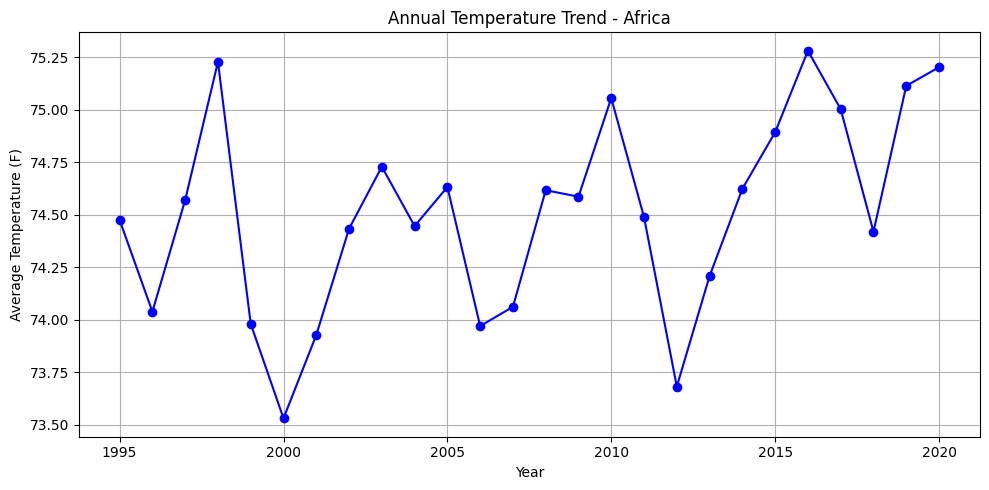

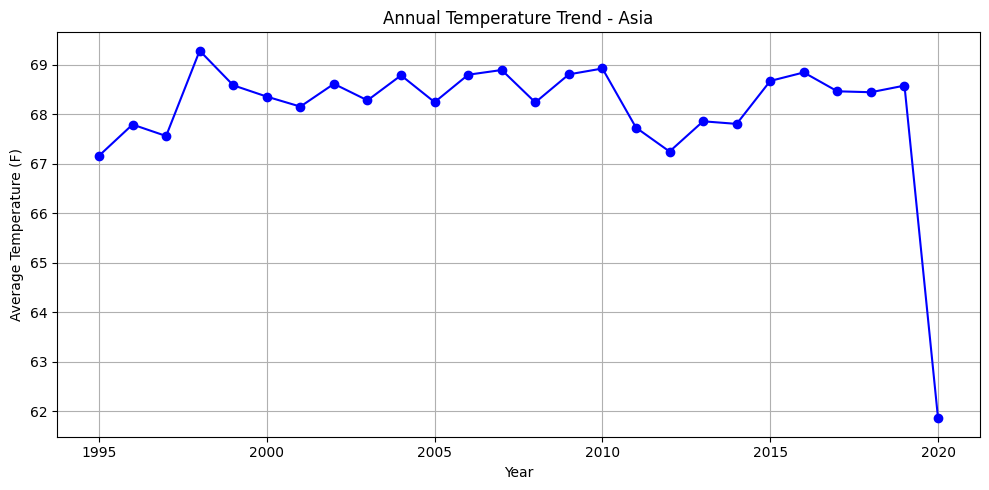

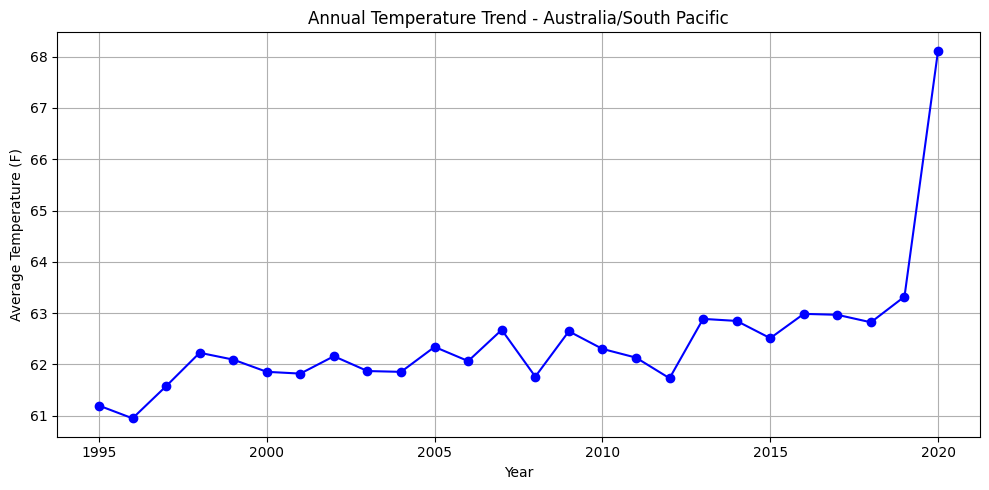

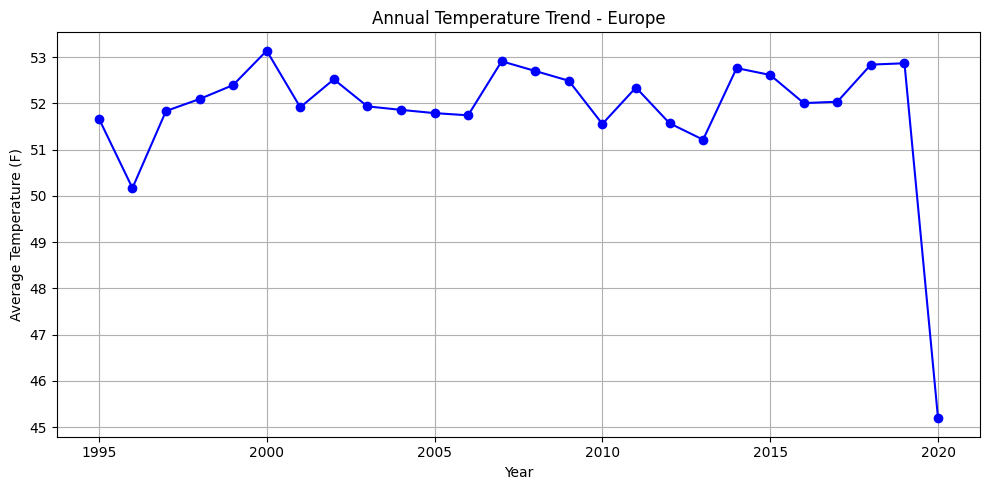

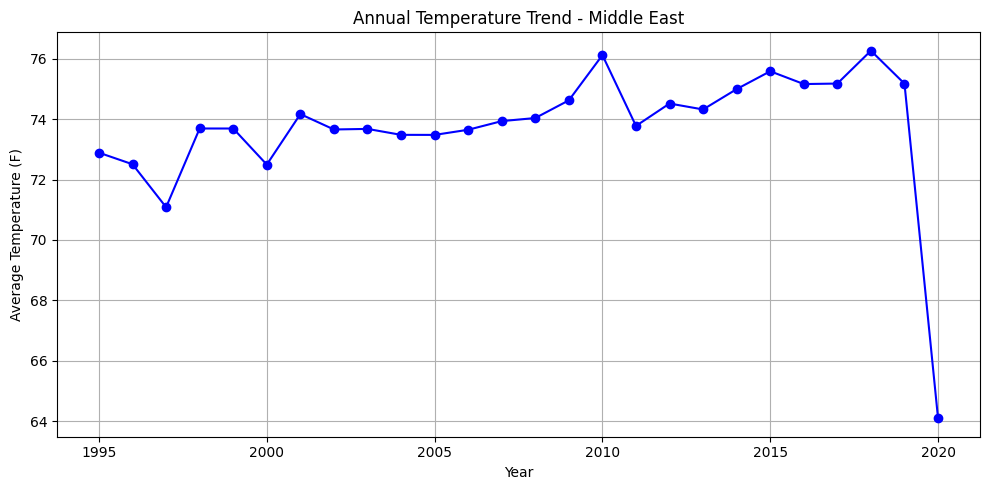

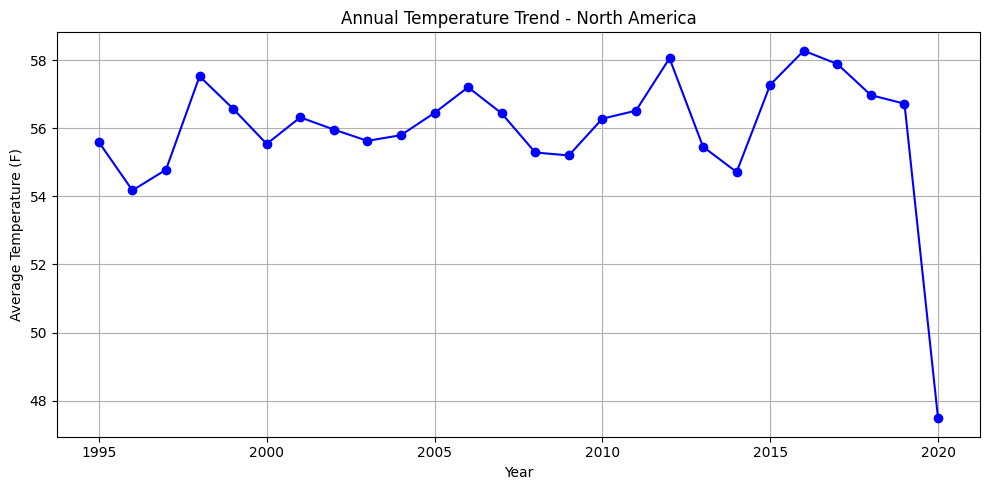

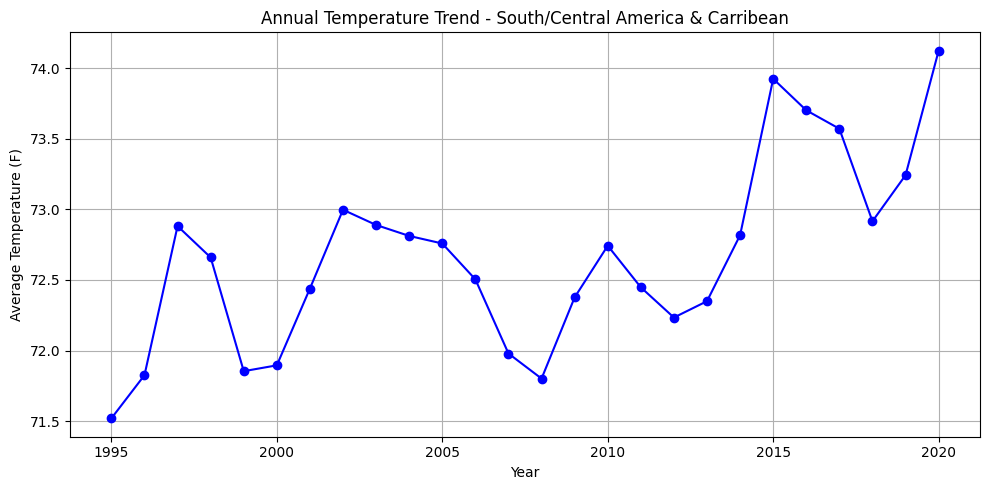

In [8]:
# Line chart: Annual average temperature trend for each region

for region in regions:
    region_df = df[df["Region"] == region]
    yearly_avg = region_df.groupby("Year")["AvgTemperature"].mean()

    plt.figure(figsize=(10, 5))
    plt.plot(yearly_avg.index, yearly_avg.values, marker="o", color="blue")
    plt.title(f"Annual Temperature Trend - {region}")
    plt.xlabel("Year")
    plt.ylabel("Average Temperature (F)")
    plt.grid()
    plt.tight_layout()
    plt.show()

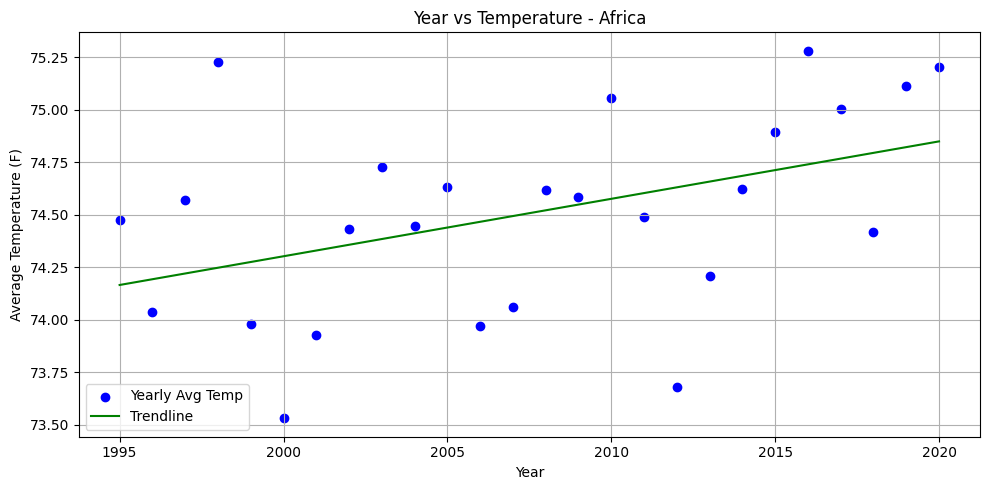

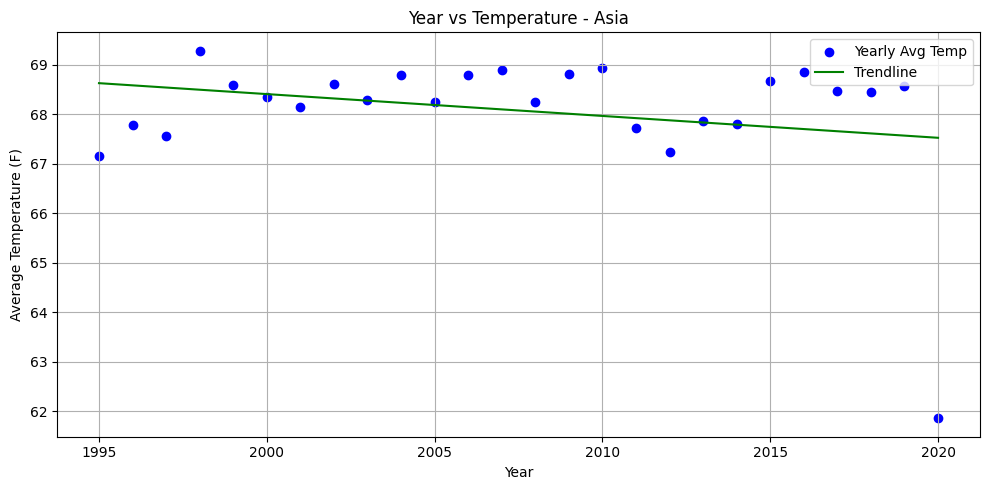

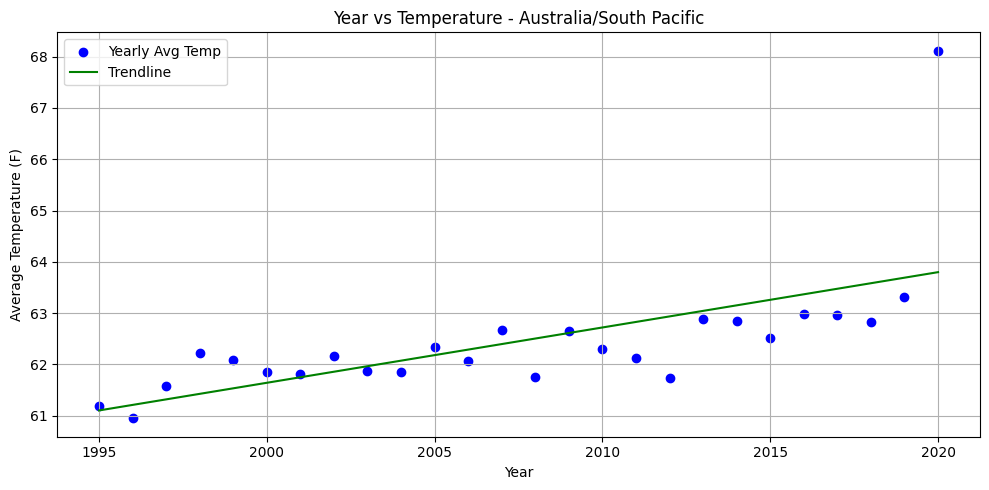

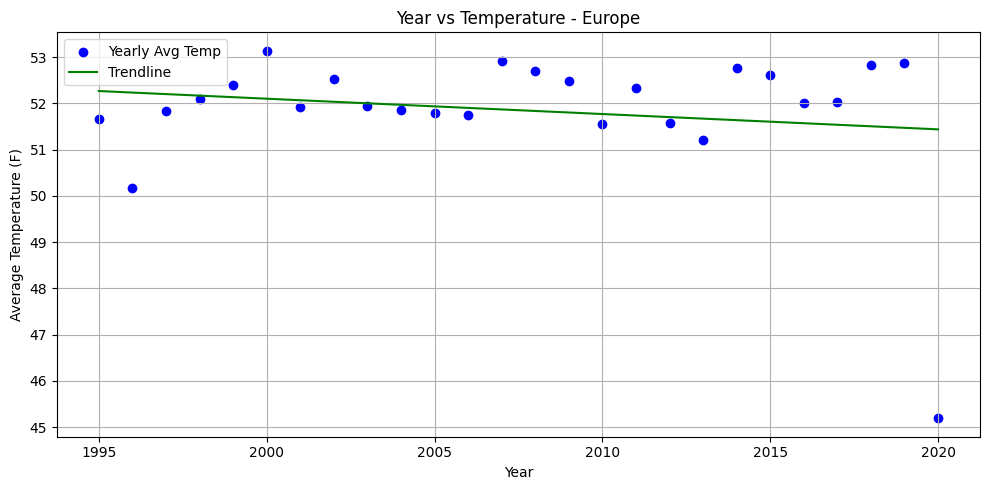

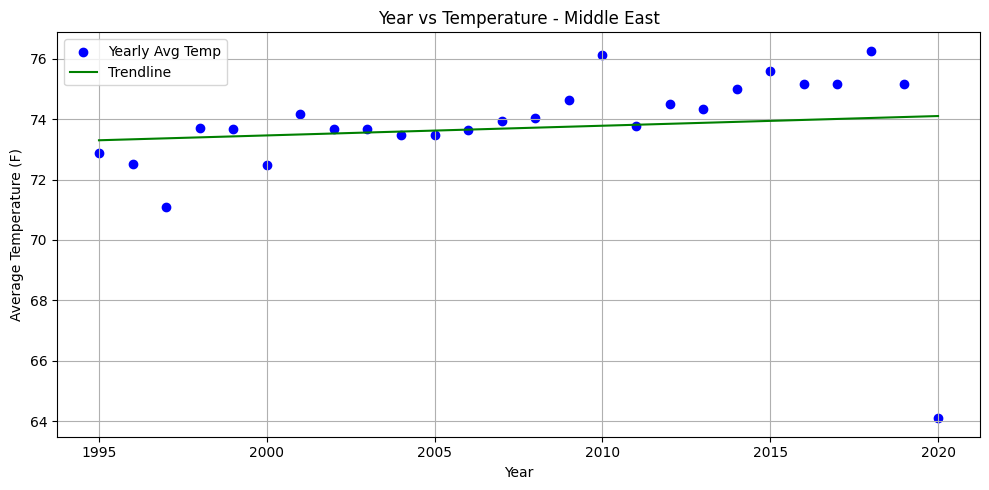

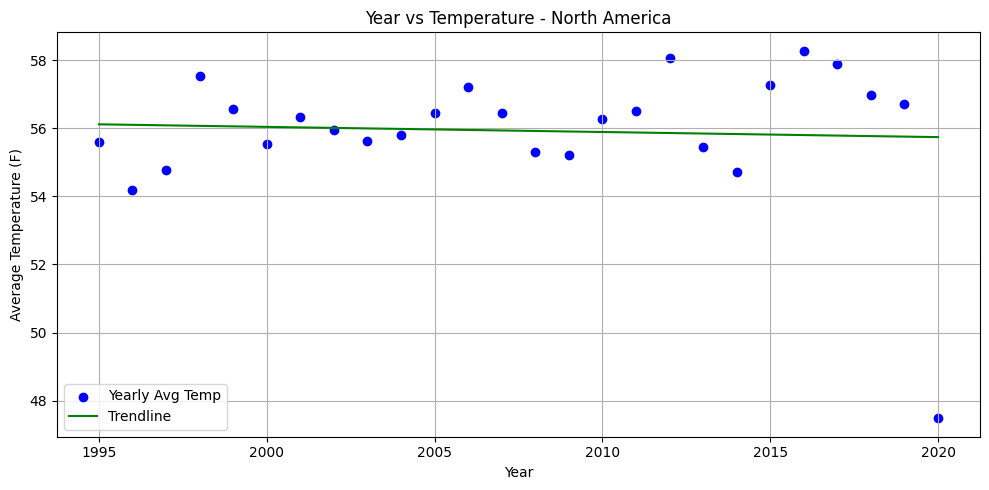

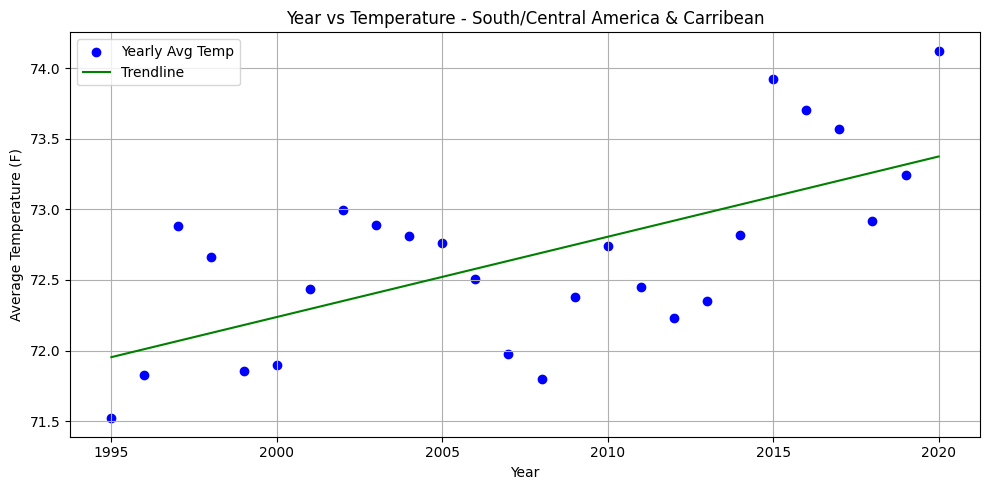

In [9]:
# Scatter plot with trendline: Year vs Average Temperature for each region

import numpy as np

for region in regions:
    region_df = df[df["Region"] == region]
    yearly_avg = region_df.groupby("Year")["AvgTemperature"].mean().reset_index()

    x = yearly_avg["Year"]
    y = yearly_avg["AvgTemperature"]

    # Fit a trendline
    m, b = np.polyfit(x, y, 1)

    plt.figure(figsize=(10, 5))
    plt.scatter(x, y, color="blue", label="Yearly Avg Temp")
    plt.plot(x, m * x + b, color="green", label="Trendline")
    plt.title(f"Year vs Temperature - {region}")
    plt.xlabel("Year")
    plt.ylabel("Average Temperature (F)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()